# Preliminary molecular-property data analysis

This notebook performs reproducible exploratory analysis of the supplied molecular dataset. The main target is the HOMO–LUMO gap (`gap`, stored energy units; README says eV, verified below); no predictive models are trained.

## Notebook contract

**Goal:** characterize data quality, target behavior, molecular diversity, and leakage risks before modeling.  
**Inputs:** `datasets/base.csv` and the supplied molecular JSON loader.  
**Outputs:** EDA figures in `outputs/figures/eda/` and summary tables in `outputs/tables/`.  
**Main questions:** Is the target trustworthy, are labeled and unlabeled molecules comparable, and which conformer-derived features are suitable for modeling?


## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
# Standard library
from collections import Counter
import warnings

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.decomposition import PCA

# Project
from src.analysis import empirical_ks, missing_patterns, residualize
from src.config import DATA_PATH, EDA_FIGURE_DIR, PROJECT_ROOT, RANDOM_SEED, TABLE_DIR
from src.data import finite_complete_rows, load_dataset
from src.features import graph_metadata, normalize_bonds, scaffold_smiles
from src.loaders import mol_json_to_fingerprint, mol_json_to_graph
from src.plotting import configure_matplotlib, save_figure


In [3]:
ROOT = PROJECT_ROOT
FIGURE_DIR = EDA_FIGURE_DIR
RANDOM_STATE = RANDOM_SEED
rng = np.random.default_rng(RANDOM_STATE)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
configure_matplotlib()

df = load_dataset(DATA_PATH)
required = {"mol_id", "json_conformer", "gap"}
assert required.issubset(df.columns)
print(f"Loaded {len(df):,} molecules from {DATA_PATH.relative_to(ROOT)}")


Loaded 116,492 molecules from datasets/base.csv


## 2. Dataset overview

In [4]:
overview = pd.DataFrame({
    "value": [
        df.shape,
        int(df.duplicated().sum()),
        int(df["mol_id"].duplicated().sum()),
        f"{df.memory_usage(deep=True).sum() / 2**20:,.1f} MiB",
    ]
}, index=["shape", "duplicate_rows", "duplicate_mol_ids", "memory_usage"])
display(overview)
display(pd.DataFrame({"dtype": df.dtypes.astype(str), "missing": df.isna().sum(),
                      "missing_pct": 100 * df.isna().mean()}))

numeric_cols = df.select_dtypes(include=np.number).columns
numerical_summary = df[numeric_cols].describe().T
numerical_summary["missing"] = df[numeric_cols].isna().sum()
numerical_summary.to_csv(TABLE_DIR / "numerical_summary.csv")
display(numerical_summary)

,value
shape,"(116492, 22)"
duplicate_rows,0
duplicate_mol_ids,0
memory_usage,176.0 MiB


,dtype,missing,missing_pct
mol_id,int64,0,0.000000
json_conformer,str,0,0.000000
A,float64,0,0.000000
B,float64,0,0.000000
C,float64,0,0.000000
mu,float64,0,0.000000
alpha,float64,0,0.000000
homo,float64,62653,53.783092
lumo,float64,62653,53.783092
gap,float64,59356,50.952855


,count,mean,std,min,25%,50%,75%,max,missing
mol_id,116492.0,58245.500000,33628.488116,0.000000,29122.750000,58245.500000,87368.250000,116491.000000,0
A,116492.0,10.767531,1939.849624,0.000000,2.553898,3.087225,3.832250,619867.683140,0
B,116492.0,1.405823,1.685024,0.337120,1.090937,1.369010,1.652763,437.903860,0
C,116492.0,1.126199,1.162772,0.331180,0.910145,1.080255,1.280482,282.945450,0
mu,116492.0,2.678558,1.505409,0.000000,1.577600,2.485350,3.607225,25.202200,0
alpha,116492.0,75.304935,8.177420,6.310000,70.510000,75.630000,80.630000,143.530000,0
homo,53839.0,-0.244585,0.319790,-26.660000,-0.252800,-0.241200,-0.228800,-0.117700,62653
lumo,53839.0,0.011668,0.063248,-5.600000,-0.023000,0.012300,0.049800,2.900000,62653
gap,57136.0,0.256125,0.345281,0.062300,0.216900,0.249700,0.288600,34.290000,59356
r2,116492.0,1190.710867,280.849563,19.000200,1018.832250,1148.132750,1310.453250,3374.753200,0


## 3. Target analysis

Only non-missing target values are used below. Outliers are identified descriptively and retained.

,gap_stored_units
count,57136.000000
mean,0.256125
std,0.345281
min,0.062300
25%,0.216900
50%,0.249700
75%,0.288600
max,34.290000
skewness,80.615555
IQR_outliers,42.000000


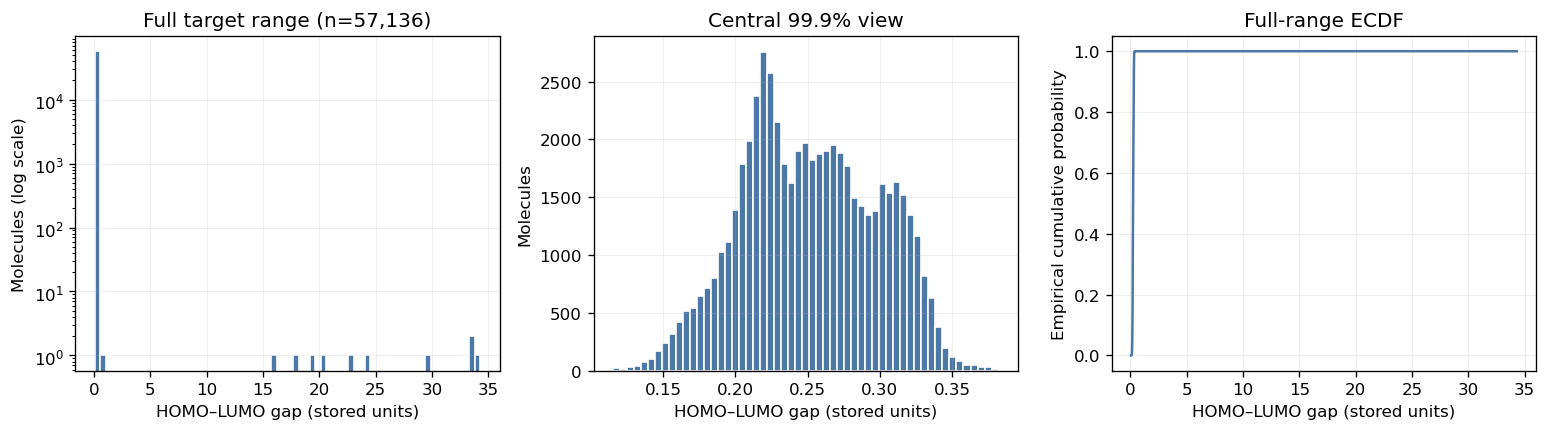

The full-range histogram uses a logarithmic count axis because bin counts span several orders of magnitude. The central panel displays [0.1145, 0.3825] (the 0.05th–99.95th percentiles); this clipping is visual only and all statistics retain every labeled value.

In [5]:
gap = df["gap"].dropna()
q1, q3 = gap.quantile([0.25, 0.75])
iqr = q3 - q1
outlier_count = int(((gap < q1 - 1.5 * iqr) | (gap > q3 + 1.5 * iqr)).sum())
target_summary = gap.describe().to_frame("gap_stored_units")
target_summary.loc["skewness"] = gap.skew()
target_summary.loc["IQR_outliers"] = outlier_count
display(target_summary)

zoom_low, zoom_high = gap.quantile([0.0005, 0.9995])
fig, axes = plt.subplots(1, 3, figsize=(13, 3.7))
axes[0].hist(gap, bins=70, color="#4C78A8", edgecolor="white", log=True)
axes[0].set(xlabel="HOMO–LUMO gap (stored units)", ylabel="Molecules (log scale)",
            title=f"Full target range (n={len(gap):,})")
central_gap = gap[gap.between(zoom_low, zoom_high)]
axes[1].hist(central_gap, bins=55, color="#4C78A8", edgecolor="white")
axes[1].set(xlabel="HOMO–LUMO gap (stored units)", ylabel="Molecules",
            title="Central 99.9% view")
x = np.sort(gap.to_numpy())
axes[2].plot(x, np.arange(1, len(x) + 1) / len(x), color="#4C78A8")
axes[2].set(xlabel="HOMO–LUMO gap (stored units)", ylabel="Empirical cumulative probability",
            title="Full-range ECDF")
save_figure("target_distribution", FIGURE_DIR)
display(Markdown(
    f"The full-range histogram uses a logarithmic count axis because bin counts span several "
    f"orders of magnitude. The central panel displays [{zoom_low:.4g}, {zoom_high:.4g}] "
    "(the 0.05th–99.95th percentiles); this clipping is visual only and all statistics retain every labeled value."
))

## 4. Molecular metadata

The supplied graph loader is used for every molecule. The helper validates coordinates and accepts bonds in either `(M, 2)` or documented `(2, M)` form.

In [6]:


graphs = mol_json_to_graph(df["json_conformer"].tolist(), n_jobs=1)
metadata = pd.DataFrame.from_records([graph_metadata(graph) for graph in graphs]).fillna(
    {c: 0 for c in []}
)
count_cols = [c for c in metadata if c.startswith(("element_", "bond_type_"))]
metadata[count_cols] = metadata[count_cols].fillna(0).astype(int)
metadata.insert(0, "mol_id", df["mol_id"].to_numpy())
metadata.to_csv(TABLE_DIR / "molecular_metadata.csv", index=False)
display(metadata.describe().T)

,count,mean,std,min,25%,50%,75%,max
mol_id,116492.0,58245.500000,33628.488116,0.000000e+00,29122.750000,58245.500000,87368.250000,116491.000000
n_atoms,116492.0,18.038037,2.947248,3.000000e+00,16.000000,18.000000,20.000000,29.000000
n_heavy_atoms,116492.0,8.795686,0.509485,1.000000e+00,9.000000,9.000000,9.000000,9.000000
n_bonds,116492.0,18.645830,3.148413,2.000000e+00,17.000000,19.000000,21.000000,28.000000
n_atom_types,116492.0,3.477715,0.582537,2.000000e+00,3.000000,4.000000,4.000000,5.000000
mean_bond_length,116492.0,1.268875,0.028262,9.621082e-01,1.247799,1.267044,1.287199,1.395782
std_bond_length,116492.0,0.194571,0.020456,1.643714e-05,0.183373,0.198302,0.209287,0.251627
radius_of_gyration,116492.0,2.393280,0.237795,6.783531e-01,2.237061,2.360748,2.510186,4.291862
max_atomic_distance,116492.0,6.543066,0.980201,1.513328e+00,5.809582,6.415088,7.054141,12.040427
element_O,116492.0,1.398002,0.885041,0.000000e+00,1.000000,1.000000,2.000000,5.000000


## 5. Molecular composition and geometry

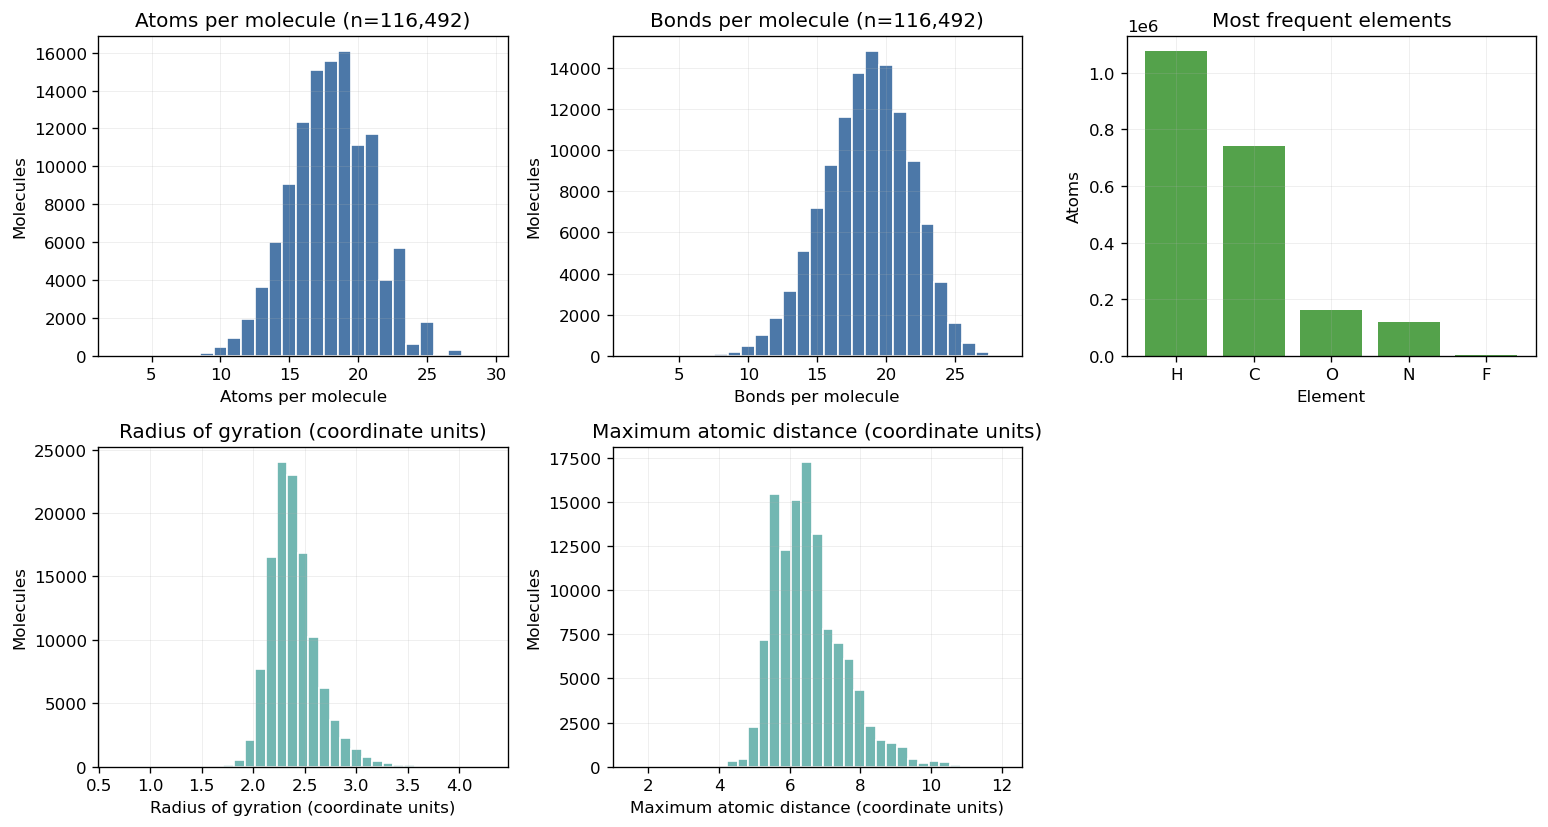

,pearson,spearman
n_bonds,0.085470,0.587862
n_atoms,0.080669,0.547096
radius_of_gyration,0.009686,0.071511
n_heavy_atoms,-0.011172,-0.065114
max_atomic_distance,0.006619,0.045026


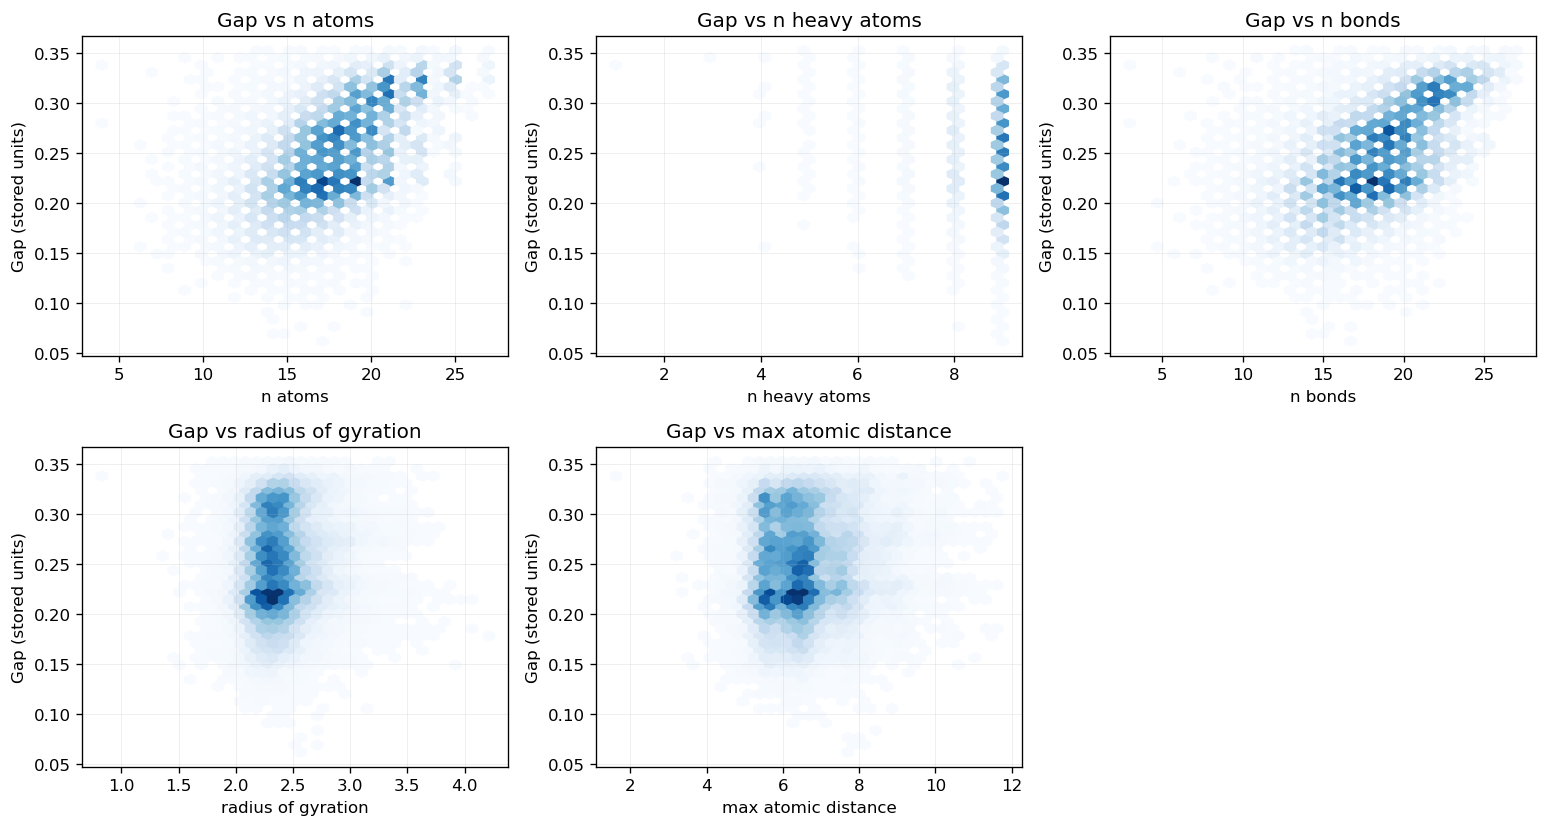

Hexagonal binning preserves all 56,853 observations in the central 99.5% target range (gap ≤ 0.3527) while making density visible. The target clipping is visual only; the Pearson and Spearman correlations above use the complete labeled data.

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
discrete_specs = [("n_atoms", "Atoms per molecule"), ("n_bonds", "Bonds per molecule")]
for ax, (column, label) in zip(axes[0, :2], discrete_specs):
    values = metadata[column].dropna().astype(int)
    bins = np.arange(values.min() - .5, values.max() + 1.5, 1)
    ax.hist(values, bins=bins, color="#4C78A8", edgecolor="white")
    ax.set(title=f"{label} (n={len(values):,})", xlabel=label, ylabel="Molecules")
for ax, column, label in [
    (axes[1, 0], "radius_of_gyration", "Radius of gyration (coordinate units)"),
    (axes[1, 1], "max_atomic_distance", "Maximum atomic distance (coordinate units)"),
]:
    values = metadata[column].dropna()
    ax.hist(values, bins=35, color="#72B7B2", edgecolor="white")
    ax.set(title=label, xlabel=label, ylabel="Molecules")
element_totals = metadata.filter(like="element_").sum().sort_values(ascending=False).head(12)
axes[0, 2].bar(element_totals.index.str.replace("element_", ""), element_totals.values, color="#54A24B")
axes[0, 2].set(title="Most frequent elements", xlabel="Element", ylabel="Atoms")
axes[1, 2].axis("off")
save_figure("composition_and_geometry", FIGURE_DIR)

descriptor_cols = ["n_atoms", "n_heavy_atoms", "n_bonds", "radius_of_gyration", "max_atomic_distance"]
analysis = metadata.set_index("mol_id")[descriptor_cols].join(df.set_index("mol_id")["gap"])
descriptor_correlations = pd.DataFrame({
    "pearson": analysis.corr(method="pearson")["gap"].drop("gap"),
    "spearman": analysis.corr(method="spearman")["gap"].drop("gap"),
}).sort_values("spearman", key=abs, ascending=False)
display(descriptor_correlations)

plot_data = analysis.dropna(subset=["gap"])
gap_limit = plot_data["gap"].quantile(.995)
central = plot_data[plot_data["gap"] <= gap_limit]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, column in zip(axes.flat, descriptor_cols):
    hb = ax.hexbin(central[column], central["gap"], gridsize=35, mincnt=1, cmap="Blues")
    ax.set(xlabel=column.replace("_", " "), ylabel="Gap (stored units)", title=f"Gap vs {column.replace('_', ' ')}")
axes.flat[-1].axis("off")
save_figure("gap_vs_structural_descriptors", FIGURE_DIR)
display(Markdown(
    f"Hexagonal binning preserves all {len(central):,} observations in the central 99.5% target range "
    f"(gap ≤ {gap_limit:.4g}) while making density visible. The target clipping is visual only; "
    "the Pearson and Spearman correlations above use the complete labeled data."
))

## 6. Other molecular properties

Correlations among supplied numerical properties are descriptive. `homo`, `lumo`, and other target columns are outcomes, not ordinary predictive inputs: using them can leak target information.

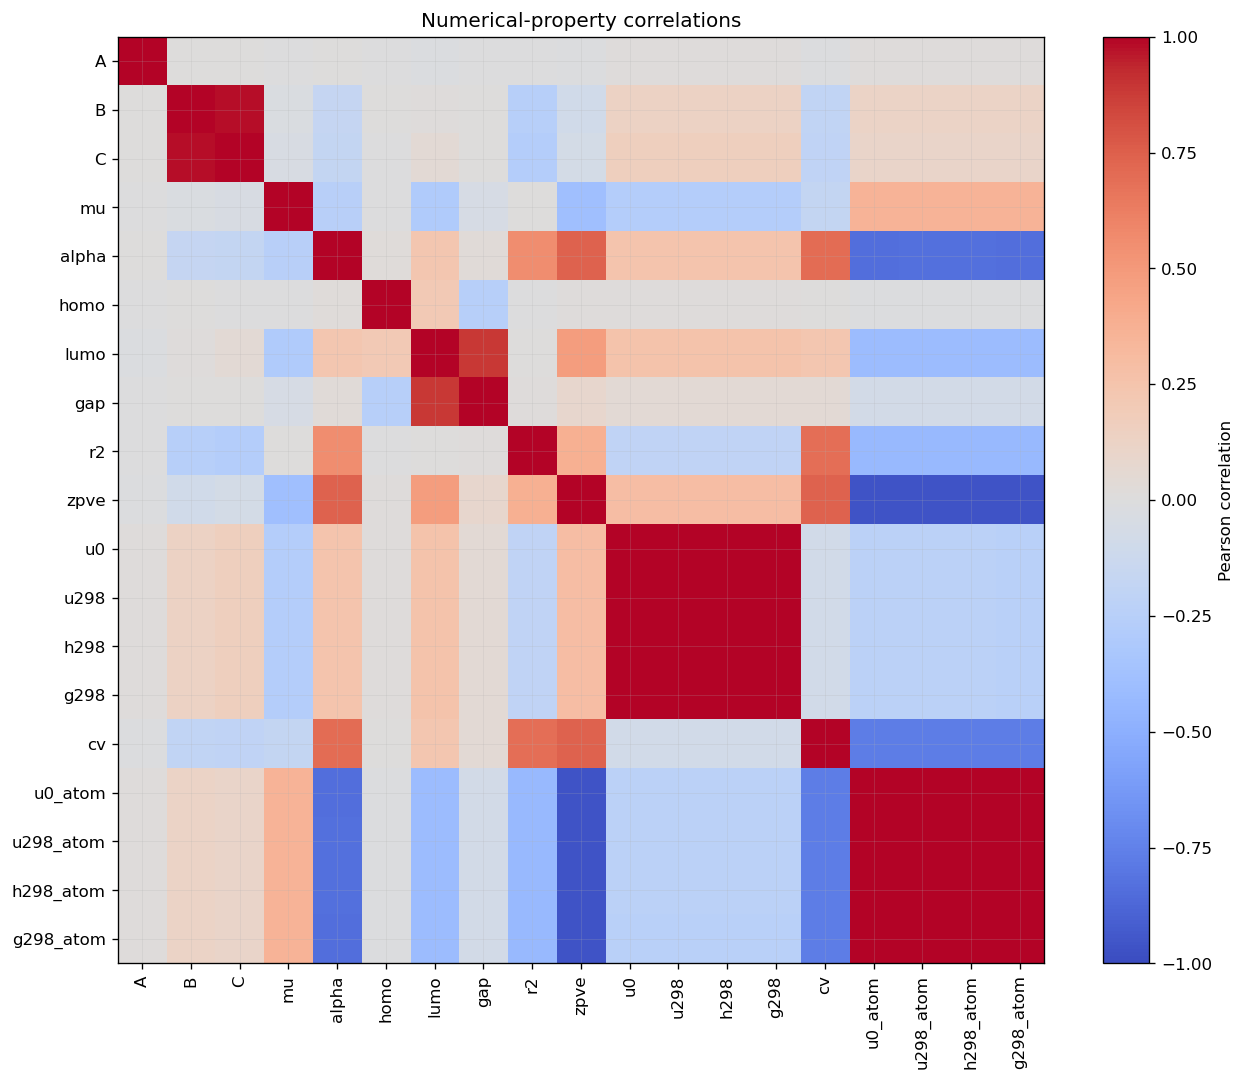

,pearson,spearman
lumo,0.888640,0.890110
homo,-0.257688,-0.229580
zpve,0.084586,0.569994
h298_atom,-0.072756,-0.488156
u298_atom,-0.072687,-0.487675
u0_atom,-0.072520,-0.486538
g298_atom,-0.071772,-0.480736
mu,-0.052073,-0.320326
cv,0.043118,0.308822
u298,0.039655,0.248417


Rows with all orbital values: 17,567
Mean absolute residual |gap - (lumo - homo)|: 2.47737e-05 stored units
Maximum absolute residual: 0.0001 stored units


In [8]:
property_numeric = df.select_dtypes(include=np.number).drop(columns=["mol_id"], errors="ignore")
corr = property_numeric.corr()
fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set(xticks=range(len(corr)), yticks=range(len(corr)),
       xticklabels=corr.columns, yticklabels=corr.index, title="Numerical-property correlations")
plt.setp(ax.get_xticklabels(), rotation=90)
fig.colorbar(image, ax=ax, label="Pearson correlation")
save_figure("numerical_correlation_heatmap", FIGURE_DIR)

target_correlations = pd.DataFrame({
    "pearson": property_numeric.corr(method="pearson")["gap"].drop("gap"),
    "spearman": property_numeric.corr(method="spearman")["gap"].drop("gap"),
}).sort_values("pearson", key=abs, ascending=False)
target_correlations.to_csv(TABLE_DIR / "target_correlations.csv")
display(target_correlations)

orbital = finite_complete_rows(df, ["gap", "lumo", "homo"])
orbital_residual = orbital["gap"] - (orbital["lumo"] - orbital["homo"])
print(f"Rows with all orbital values: {len(orbital):,}")
print(f"Mean absolute residual |gap - (lumo - homo)|: {orbital_residual.abs().mean():.6g} stored units")
print(f"Maximum absolute residual: {orbital_residual.abs().max():.6g} stored units")

## 7. Morgan fingerprints

{'shape': (116492, 2048), 'overall_density': 0.009945157178175325, 'unused_bits': 0, 'duplicate_fingerprints': 658}


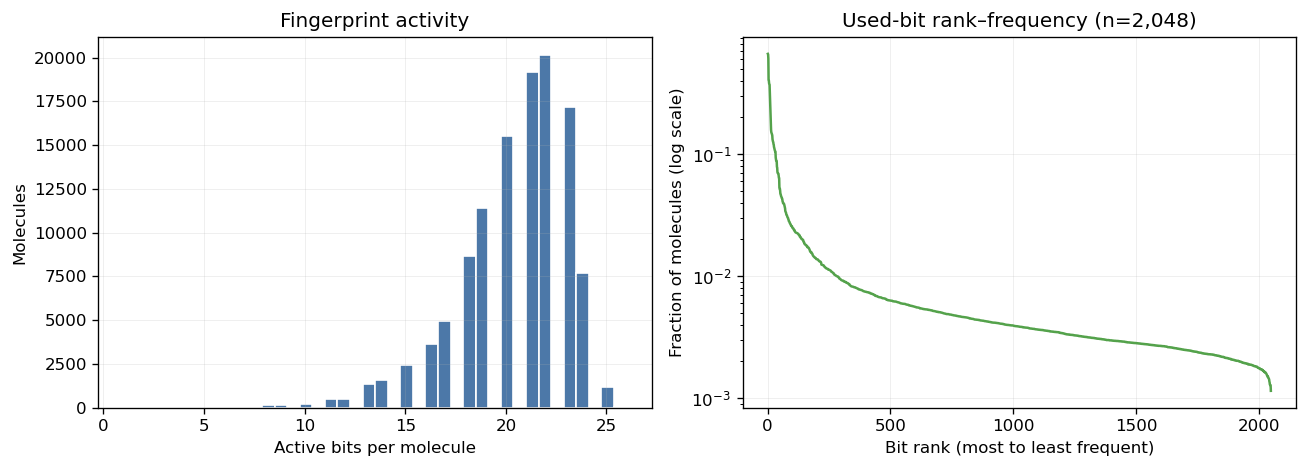

The bit-frequency panel uses a logarithmic y-axis because positive used-bit frequencies span several orders of magnitude; unused bits are reported numerically rather than placed on a log axis.

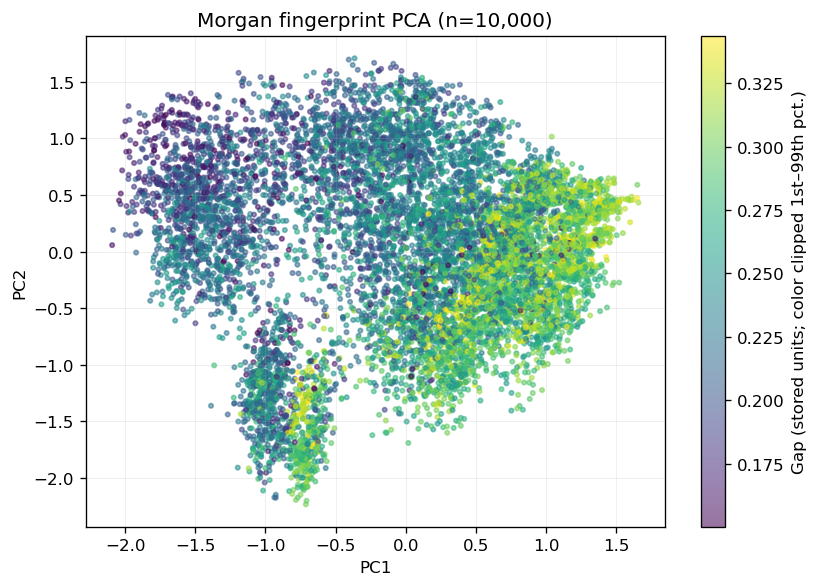

All sampled molecules are displayed; only the color mapping is percentile-clipped so rare target extremes do not erase central color variation.

In [9]:
fingerprints = mol_json_to_fingerprint(
    df["json_conformer"], radius=2, n_bits=2048,
)
active_bits = fingerprints.sum(axis=1)
bit_frequency = fingerprints.mean(axis=0)
packed = np.packbits(fingerprints, axis=1)
duplicate_fingerprints = int(pd.DataFrame(packed).duplicated().sum())
print({"shape": fingerprints.shape, "overall_density": float(fingerprints.mean()),
       "unused_bits": int((bit_frequency == 0).sum()), "duplicate_fingerprints": duplicate_fingerprints})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(active_bits, bins=40, color="#4C78A8", edgecolor="white")
axes[0].set(xlabel="Active bits per molecule", ylabel="Molecules", title="Fingerprint activity")
used_frequency = np.sort(bit_frequency[bit_frequency > 0])[::-1]
axes[1].plot(np.arange(1, len(used_frequency) + 1), used_frequency, color="#54A24B")
axes[1].set_yscale("log")
axes[1].set(xlabel="Bit rank (most to least frequent)", ylabel="Fraction of molecules (log scale)",
            title=f"Used-bit rank–frequency (n={len(used_frequency):,})")
save_figure("fingerprint_sparsity", FIGURE_DIR)
display(Markdown(
    "The bit-frequency panel uses a logarithmic y-axis because positive used-bit frequencies span "
    "several orders of magnitude; unused bits are reported numerically rather than placed on a log axis."
))

pca_pool = np.flatnonzero(df["gap"].notna().to_numpy())
pca_idx = rng.choice(pca_pool, size=min(10_000, len(pca_pool)), replace=False)
pca_xy = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(fingerprints[pca_idx])
pca_gap = df["gap"].to_numpy()[pca_idx]
color_low, color_high = np.quantile(pca_gap, [.01, .99])
plt.figure(figsize=(7, 5))
scatter = plt.scatter(pca_xy[:, 0], pca_xy[:, 1], c=pca_gap, vmin=color_low, vmax=color_high,
                      s=7, alpha=0.55, cmap="viridis", rasterized=True)
plt.colorbar(scatter, label="Gap (stored units; color clipped 1st–99th pct.)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title(f"Morgan fingerprint PCA (n={len(pca_idx):,})")
save_figure("fingerprint_pca", FIGURE_DIR)
display(Markdown("All sampled molecules are displayed; only the color mapping is percentile-clipped so rare target extremes do not erase central color variation."))

## 8. Molecular similarity

Pairwise Tanimoto similarity is computed only on a fixed labeled sample; this avoids a full quadratic matrix.

,similarity_bin,pair_count,median_absolute_gap_difference
0,"[0.0, 0.1)",228183,0.0517
1,"[0.1, 0.2)",84034,0.0391
2,"[0.2, 0.3)",6848,0.0256
3,"[0.3, 0.4)",465,0.0196
4,"[0.4, 0.5)",55,0.0169
5,"[0.5, 0.6)",13,0.0164
6,"[0.6, 0.7)",1,0.0040
7,"[0.7, 0.8)",0,NaN
8,"[0.8, 0.9)",1,0.0004
9,"[0.9, 1.0)",0,NaN


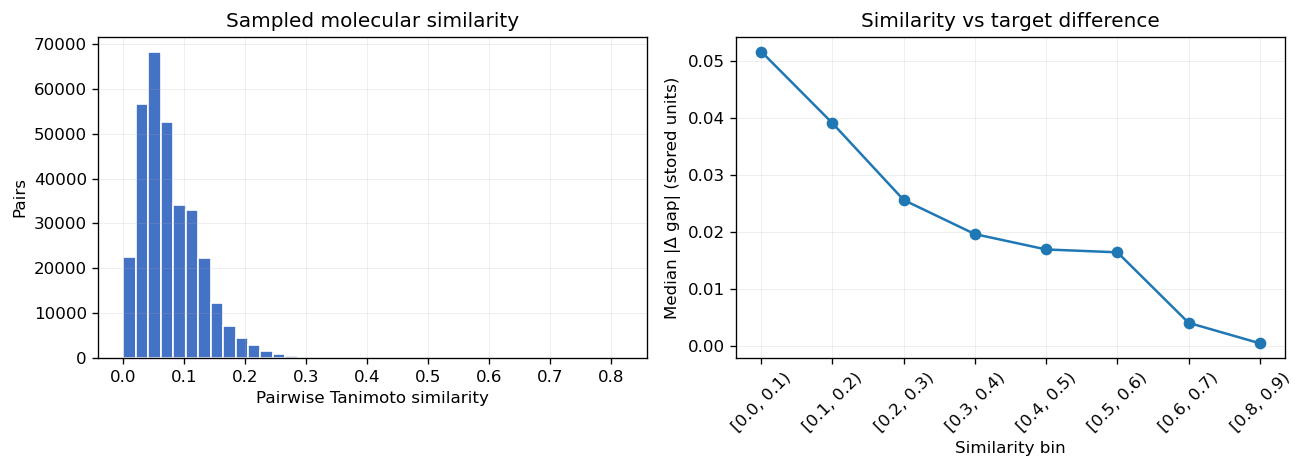

PosixPath('/home/ldibari/AQEMIA/MindTheGap/outputs/figures/eda/similarity_and_gap_difference.png')

In [10]:
similarity_idx = rng.choice(np.flatnonzero(df["gap"].notna().to_numpy()),
                            size=min(800, df["gap"].notna().sum()), replace=False)
sample_fp = fingerprints[similarity_idx].astype(np.int32)
sample_gap = df["gap"].to_numpy()[similarity_idx]
similarities, gap_differences = [], []
for i in range(len(sample_fp) - 1):
    intersection = sample_fp[i + 1:] @ sample_fp[i]
    union = sample_fp[i + 1:].sum(axis=1) + sample_fp[i].sum() - intersection
    similarities.append(intersection / np.maximum(union, 1))
    gap_differences.append(np.abs(sample_gap[i + 1:] - sample_gap[i]))
similarities = np.concatenate(similarities)
gap_differences = np.concatenate(gap_differences)

bins = np.array([0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1.000001])
similarity_bin = pd.cut(similarities, bins=bins, right=False)
similarity_table = (
    pd.DataFrame({"similarity_bin": similarity_bin, "absolute_gap_difference": gap_differences})
    .groupby("similarity_bin", observed=False)["absolute_gap_difference"]
    .agg(pair_count="size", median_absolute_gap_difference="median")
    .reset_index()
)
similarity_table["similarity_bin"] = similarity_table["similarity_bin"].astype(str)
similarity_table.to_csv(TABLE_DIR / "similarity_vs_gap_difference.csv", index=False)
display(similarity_table)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(similarities, bins=40, color="#4472C4", edgecolor="white")
axes[0].set(xlabel="Pairwise Tanimoto similarity", ylabel="Pairs", title="Sampled molecular similarity")
valid_bins = similarity_table["pair_count"] > 0
axes[1].plot(similarity_table.loc[valid_bins, "similarity_bin"],
             similarity_table.loc[valid_bins, "median_absolute_gap_difference"], marker="o")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set(xlabel="Similarity bin", ylabel="Median |Δ gap| (stored units)", title="Similarity vs target difference")
save_figure("similarity_and_gap_difference", FIGURE_DIR)

## 9. Scaffold analysis

Bemis–Murcko scaffolds group molecules by core structure. Their frequency profile motivates comparing random splits with scaffold splits later: the latter better tests transfer to unseen cores.

,metric,value
0,unique_scaffolds,35420.000000
1,singleton_scaffolds,26404.000000
2,empty_scaffold_proportion,0.103269
3,top_10_molecule_percentage,19.131786


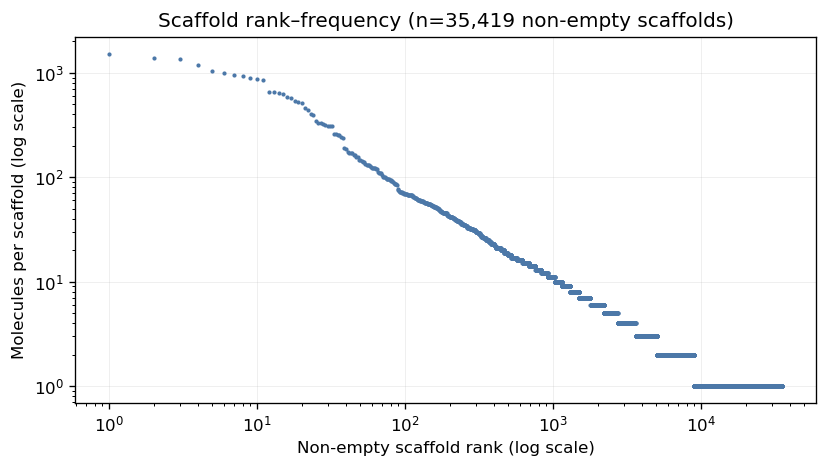

Both axes are logarithmic because scaffold ranks and strictly positive occurrence counts span several orders of magnitude. The rank–frequency view exposes the long tail more directly than histogram binning.

In [11]:

scaffolds = pd.Series([scaffold_smiles(js) for js in df["json_conformer"]], name="scaffold")
scaffold_counts = scaffolds.value_counts(dropna=False)
nonempty_counts = scaffold_counts.drop(index="", errors="ignore")
scaffold_summary = pd.DataFrame({
    "metric": ["unique_scaffolds", "singleton_scaffolds", "empty_scaffold_proportion",
               "top_10_molecule_percentage"],
    "value": [scaffolds.nunique(), int((nonempty_counts == 1).sum()),
              float((scaffolds == "").mean()), float(100 * scaffold_counts.head(10).sum() / len(scaffolds))],
})
size_distribution = scaffold_counts.value_counts().sort_index().rename_axis("molecules_per_scaffold").reset_index(name="scaffold_count")
scaffold_summary.to_csv(TABLE_DIR / "scaffold_summary.csv", index=False)
display(scaffold_summary)

ranked_counts = np.sort(nonempty_counts.to_numpy())[::-1]
plt.figure(figsize=(7, 4))
plt.loglog(np.arange(1, len(ranked_counts) + 1), ranked_counts, marker=".", linestyle="none",
           markersize=3, color="#4C78A8")
plt.xlabel("Non-empty scaffold rank (log scale)")
plt.ylabel("Molecules per scaffold (log scale)")
plt.title(f"Scaffold rank–frequency (n={len(ranked_counts):,} non-empty scaffolds)")
save_figure("scaffold_size_distribution", FIGURE_DIR)
display(Markdown(
    "Both axes are logarithmic because scaffold ranks and strictly positive occurrence counts span "
    "several orders of magnitude. The rank–frequency view exposes the long tail more directly than histogram binning."
))


## 10. Data-quality checks

In [12]:
finite_issues = {
    c: int((~np.isfinite(df[c].dropna().to_numpy())).sum())
    for c in df.select_dtypes(include=np.number)
}
nunique = df.nunique(dropna=True)
constant = nunique[nunique <= 1].index.tolist()
near_constant = []
for c in df.columns:
    counts = df[c].value_counts(dropna=False, normalize=True)
    if len(counts) > 1 and counts.iloc[0] >= 0.99:
        near_constant.append(c)

quality_checks = pd.Series({
    "duplicate_mol_ids": int(df["mol_id"].duplicated().sum()),
    "duplicate_json_strings": int(df["json_conformer"].duplicated().sum()),
    "duplicate_fingerprints": duplicate_fingerprints,
    "numeric_non_finite_values": int(sum(finite_issues.values())),
    "constant_columns": constant,
    "nearly_constant_columns_99pct": near_constant,
    "gap_equals_lumo_minus_homo_max_abs_residual":
        float(orbital_residual.abs().max()) if len(orbital_residual) else np.nan,
})
display(quality_checks.to_frame("result"))
print("Potential deterministic leakage relationship: gap = lumo - homo where all three are supplied.")

,result
duplicate_mol_ids,0
duplicate_json_strings,0
duplicate_fingerprints,658
numeric_non_finite_values,0
constant_columns,[]
nearly_constant_columns_99pct,[]
gap_equals_lumo_minus_homo_max_abs_residual,0.0001


Potential deterministic leakage relationship: gap = lumo - homo where all three are supplied.


## 11. Preliminary findings and modeling implications

In [13]:
heavy_elements = element_totals.drop(labels=["element_H"], errors="ignore")
top_elements = ", ".join(heavy_elements.head(4).index.str.replace("element_", ""))
best_3d = descriptor_correlations["spearman"].abs().idxmax()
best_3d_rho = descriptor_correlations.loc[best_3d, "spearman"]
nonempty_similarity = similarity_table.loc[similarity_table["pair_count"] > 0]
similarity_trend = "decreases" if (
    nonempty_similarity["median_absolute_gap_difference"].iloc[-1]
    < nonempty_similarity["median_absolute_gap_difference"].iloc[0]
) else "does not decrease consistently"

display(Markdown(f'''
## Preliminary findings and modeling implications

- **Dataset quality:** {len(df):,} rows, {df["gap"].notna().sum():,} labeled targets, {int(df["mol_id"].duplicated().sum())} duplicate IDs, {int(df["json_conformer"].duplicated().sum())} duplicate molecular JSON strings, and {sum(finite_issues.values())} non-finite numerical values (excluding missing values).
- **Target distribution:** mean {gap.mean():.3f}, standard deviation {gap.std():.3f} in stored units, skewness {gap.skew():.3f}, with {outlier_count:,} IQR-flagged values retained.
- **Molecular size and composition:** median {metadata["n_atoms"].median():.0f} atoms and {metadata["n_bonds"].median():.0f} bonds; the most frequent non-hydrogen elements are {top_elements}.
- **Chemical diversity:** {scaffolds.nunique():,} unique scaffolds; {(scaffolds == "").mean():.1%} are empty/acyclic and {100 * scaffold_counts.head(10).sum() / len(scaffolds):.1f}% of molecules belong to the ten most frequent scaffold labels.
- **Fingerprint sparsity:** mean density {fingerprints.mean():.3%}, {(bit_frequency == 0).sum():,} unused bits, and {duplicate_fingerprints:,} duplicate fingerprints.
- **Similarity versus target:** median absolute target difference {similarity_trend} from the lowest to highest populated similarity bins in the reproducible sample.
- **Simple 3D descriptors:** the strongest absolute Spearman association is `{best_3d}` (ρ={best_3d_rho:.3f}); these descriptors may add geometric signal but are unlikely to capture chemistry alone.
- **Leakage risk:** `gap ≈ lumo - homo` has maximum absolute residual {orbital_residual.abs().max():.3g} stored units. Orbital energies and other supplied target properties must be excluded from ordinary predictive features.
- **Later hypotheses:** compare size/geometry descriptors against connectivity fingerprints, test whether their combination adds value, and measure generalization under both random and scaffold-aware splits.

Proposed next experiments (not implemented here):

1. Constant baseline.
2. Simple molecular descriptors.
3. Morgan fingerprints with classical ML.
4. Combined 2D and 3D descriptors.
5. Optional graph or geometric neural network.
6. Random versus scaffold split.
'''))


## Preliminary findings and modeling implications

- **Dataset quality:** 116,492 rows, 57,136 labeled targets, 0 duplicate IDs, 0 duplicate molecular JSON strings, and 0 non-finite numerical values (excluding missing values).
- **Target distribution:** mean 0.256, standard deviation 0.345 in stored units, skewness 80.616, with 42 IQR-flagged values retained.
- **Molecular size and composition:** median 18 atoms and 19 bonds; the most frequent non-hydrogen elements are C, O, N, F.
- **Chemical diversity:** 35,420 unique scaffolds; 10.3% are empty/acyclic and 19.1% of molecules belong to the ten most frequent scaffold labels.
- **Fingerprint sparsity:** mean density 0.995%, 0 unused bits, and 658 duplicate fingerprints.
- **Similarity versus target:** median absolute target difference decreases from the lowest to highest populated similarity bins in the reproducible sample.
- **Simple 3D descriptors:** the strongest absolute Spearman association is `n_bonds` (ρ=0.588); these descriptors may add geometric signal but are unlikely to capture chemistry alone.
- **Leakage risk:** `gap ≈ lumo - homo` has maximum absolute residual 0.0001 stored units. Orbital energies and other supplied target properties must be excluded from ordinary predictive features.
- **Later hypotheses:** compare size/geometry descriptors against connectivity fingerprints, test whether their combination adds value, and measure generalization under both random and scaffold-aware splits.

Proposed next experiments (not implemented here):

1. Constant baseline.
2. Simple molecular descriptors.
3. Morgan fingerprints with classical ML.
4. Combined 2D and 3D descriptors.
5. Optional graph or geometric neural network.
6. Random versus scaffold split.


## Pre-modeling validation

These checks clarify dataset partitions, units, unusual targets, distribution shift, descriptor roles, and leakage boundaries before any model is fitted.

### Labeled and unlabeled rows

In [14]:
labeled_mask = df["gap"].notna()
unlabeled_mask = ~labeled_mask
subset_counts = pd.Series({
    "labeled": int(labeled_mask.sum()),
    "unlabeled": int(unlabeled_mask.sum()),
}, name="samples")
display(subset_counts.to_frame())


display(Markdown("**Most common missing-value patterns — labeled rows**"))
display(missing_patterns(df.loc[labeled_mask]))
display(Markdown("**Most common missing-value patterns — unlabeled rows**"))
display(missing_patterns(df.loc[unlabeled_mask]))

auxiliary_targets = [
    "A", "B", "C", "mu", "alpha", "homo", "lumo", "r2", "zpve", "u0",
    "u298", "h298", "g298", "cv", "u0_atom", "u298_atom", "h298_atom", "g298_atom",
]
aux_missing = pd.DataFrame({
    "labeled_missing_pct": 100 * df.loc[labeled_mask, auxiliary_targets].isna().mean(),
    "unlabeled_missing_pct": 100 * df.loc[unlabeled_mask, auxiliary_targets].isna().mean(),
})
display(aux_missing)
print(
    "Unlabeled rows with every auxiliary target missing:",
    f"{df.loc[unlabeled_mask, auxiliary_targets].isna().all(axis=1).mean():.1%}",
)
display(Markdown(
    "The absence of `gap` defines an unlabeled subset, but no available documentation "
    "identifies it as a hidden test set; it is therefore described only as unlabeled."
))

,samples
labeled,57136
unlabeled,59356


**Most common missing-value patterns — labeled rows**

,rows
missing_columns,
"homo, lumo",26381
none,17567
lumo,6594
homo,6594


**Most common missing-value patterns — unlabeled rows**

,rows
missing_columns,
"lumo, gap",29678
"homo, gap",29678


,labeled_missing_pct,unlabeled_missing_pct
A,0.000000,0.0
B,0.000000,0.0
C,0.000000,0.0
mu,0.000000,0.0
alpha,0.000000,0.0
homo,57.713176,50.0
lumo,57.713176,50.0
r2,0.000000,0.0
zpve,0.000000,0.0
u0,0.000000,0.0


Unlabeled rows with every auxiliary target missing: 0.0%


The absence of `gap` defines an unlabeled subset, but no available documentation identifies it as a hidden test set; it is therefore described only as unlabeled.

### Target-unit and extreme-value checks

In [15]:
energy_summary = df[["gap", "homo", "lumo"]].describe(percentiles=[.001, .01, .5, .99, .999]).T
display(energy_summary)
unit_rows = df[["gap", "homo", "lumo"]].dropna()
unit_residual = unit_rows["gap"] - (unit_rows["lumo"] - unit_rows["homo"])
unit_check = pd.Series({
    "rows_compared": len(unit_rows),
    "mean_absolute_residual": unit_residual.abs().mean(),
    "median_absolute_residual": unit_residual.abs().median(),
    "maximum_absolute_residual": unit_residual.abs().max(),
})
display(unit_check.to_frame("value"))
display(Markdown(
    f"The algebraic relationship is numerically exact to about "
    f"{unit_residual.abs().max():.1g} in the stored units. The median gap "
    f"({gap.median():.3f}) and orbital-energy scale resemble **Hartree-valued QM data**, "
    "whereas the supplied README labels these columns as eV. This is a unit-documentation "
    "inconsistency to confirm with AQEMIA; no automatic conversion is applied."
))

extreme_quantiles = gap.quantile([0, .0005, .001, .01, .05, .25, .5, .75, .95, .99, .999, .9995, 1])
display(extreme_quantiles.rename("gap").to_frame())
display(Markdown("**20 smallest labeled targets**"))
display(df.loc[labeled_mask, ["mol_id", "gap"]].nsmallest(20, "gap"))
display(Markdown("**20 largest labeled targets**"))
display(df.loc[labeled_mask, ["mol_id", "gap"]].nlargest(20, "gap"))
print(f"IQR outliers retained: {outlier_count:,}; min={gap.min():.6g}, max={gap.max():.6g}")

display(Markdown("The central 99.9% target view is included in `target_distribution.png`; no second redundant histogram is generated."))


,count,mean,std,min,0.1%,1%,50%,99%,99.9%,max
gap,57136.0,0.256125,0.345281,0.0623,0.122540,0.1509,0.2497,0.3436,0.374886,34.2900
homo,53839.0,-0.244585,0.319790,-26.6600,-0.327532,-0.2954,-0.2412,-0.1764,-0.159600,-0.1177
lumo,53839.0,0.011668,0.063248,-5.6000,-0.130665,-0.0985,0.0123,0.0913,0.098700,2.9000


,value
rows_compared,17567.000000
mean_absolute_residual,0.000025
median_absolute_residual,0.000000
maximum_absolute_residual,0.000100


The algebraic relationship is numerically exact to about 0.0001 in the stored units. The median gap (0.250) and orbital-energy scale resemble **Hartree-valued QM data**, whereas the supplied README labels these columns as eV. This is a unit-documentation inconsistency to confirm with AQEMIA; no automatic conversion is applied.

,gap
0.0000,0.062300
0.0005,0.114481
0.0010,0.122540
0.0100,0.150900
0.0500,0.176200
0.2500,0.216900
0.5000,0.249700
0.7500,0.288600
0.9500,0.326800
0.9900,0.343600


**20 smallest labeled targets**

,mol_id,gap
48330,81118,0.0623
64880,61097,0.0692
105422,106267,0.0709
52576,44173,0.0766
38763,11126,0.0790
46853,41588,0.0821
39285,40384,0.0909
104710,111279,0.0938
48891,57813,0.0955
51856,17217,0.0960


**20 largest labeled targets**

,mol_id,gap
36279,79512,34.2900
36276,93259,33.7500
36274,36424,33.4700
36278,9528,29.7800
36275,35886,24.1900
36277,93240,22.8300
36281,11941,20.5800
36273,94554,19.4800
36280,64581,17.9200
36272,81026,16.1300


IQR outliers retained: 42; min=0.0623, max=34.29


The central 99.9% target view is included in `target_distribution.png`; no second redundant histogram is generated.

### Labeled–unlabeled shift and descriptor types

**Topological descriptors** encode connectivity and composition: atom counts, bond counts, element counts, and bond-type counts.  
**Geometric descriptors** use coordinates: radius of gyration, bond-length statistics, maximum atomic distance, and coordinate-covariance eigenvalues. Atom and bond counts are not 3D descriptors.

In [16]:
comparison = metadata.set_index("mol_id").reindex(df["mol_id"]).reset_index()
comparison["fingerprint_density"] = active_bits / fingerprints.shape[1]
comparison["is_labeled"] = labeled_mask.to_numpy()

shift_columns = [
    "n_atoms", "n_bonds", "n_heavy_atoms", "radius_of_gyration",
    "max_atomic_distance", "fingerprint_density",
]


shift_rows = []
for column in shift_columns:
    x = comparison.loc[comparison["is_labeled"], column].dropna()
    y = comparison.loc[~comparison["is_labeled"], column].dropna()
    pooled_sd = np.sqrt((x.var() + y.var()) / 2)
    shift_rows.append({
        "descriptor": column,
        "labeled_mean": x.mean(),
        "unlabeled_mean": y.mean(),
        "standardized_mean_difference": (x.mean() - y.mean()) / pooled_sd if pooled_sd else 0,
        "ks_statistic": empirical_ks(x, y, rng=rng),
    })
shift_table = pd.DataFrame(shift_rows).set_index("descriptor")

scaffold_by_subset = pd.crosstab(scaffolds, labeled_mask.to_numpy(), normalize="columns")
scaffold_by_subset = scaffold_by_subset.reindex(columns=[False, True], fill_value=0)
scaffold_total_variation = 0.5 * np.abs(
    scaffold_by_subset[True] - scaffold_by_subset[False]
).sum()
acyclic_by_subset = pd.Series({
    "labeled": (scaffolds[labeled_mask.to_numpy()] == "").mean(),
    "unlabeled": (scaffolds[unlabeled_mask.to_numpy()] == "").mean(),
})
display(shift_table)
display(acyclic_by_subset.rename("acyclic_proportion").to_frame())
print(f"Scaffold-frequency total-variation distance: {scaffold_total_variation:.3f}")

shift_evidence = (
    (shift_table["standardized_mean_difference"].abs() >= 0.1).any()
    or (shift_table["ks_statistic"] >= 0.1).any()
    or scaffold_total_variation >= 0.1
)
print("Evidence of labeled/unlabeled distribution shift:", "yes" if shift_evidence else "limited")

,labeled_mean,unlabeled_mean,standardized_mean_difference,ks_statistic
descriptor,,,,
n_atoms,18.037595,18.038463,-0.000295,0.00605
n_bonds,18.642467,18.649067,-0.002096,0.00600
n_heavy_atoms,8.796276,8.795118,0.002273,0.00365
radius_of_gyration,2.394935,2.391686,0.013664,0.00930
max_atomic_distance,6.549782,6.536601,0.013447,0.00880
fingerprint_density,0.009953,0.009938,0.011057,0.00870


,acyclic_proportion
labeled,0.103647
unlabeled,0.102905


Scaffold-frequency total-variation distance: 0.362
Evidence of labeled/unlabeled distribution shift: yes


### Does geometry add information beyond molecular size?

In [17]:
geometric_descriptors = [
    "radius_of_gyration", "mean_bond_length", "std_bond_length",
    "max_atomic_distance", "coordinate_cov_eigenvalue_1",
    "coordinate_cov_eigenvalue_2", "coordinate_cov_eigenvalue_3",
]
geometry_frame = metadata.set_index("mol_id")[geometric_descriptors + ["n_heavy_atoms"]].join(
    df.set_index("mol_id")["gap"]
)


geometry_rows = []
for descriptor in geometric_descriptors:
    pair = geometry_frame[[descriptor, "n_heavy_atoms", "gap"]].dropna()
    direct_pearson = pair[descriptor].corr(pair["gap"], method="pearson")
    direct_spearman = pair[descriptor].corr(pair["gap"], method="spearman")
    x_resid = residualize(pair[descriptor].to_numpy(), pair["n_heavy_atoms"].to_numpy())
    y_resid = residualize(pair["gap"].to_numpy(), pair["n_heavy_atoms"].to_numpy())
    x_rank = pair[descriptor].rank().to_numpy()
    y_rank = pair["gap"].rank().to_numpy()
    size_rank = pair["n_heavy_atoms"].rank().to_numpy()
    geometry_rows.append({
        "descriptor": descriptor,
        "direct_pearson": direct_pearson,
        "partial_pearson_given_heavy_atoms": np.corrcoef(x_resid, y_resid)[0, 1],
        "direct_spearman": direct_spearman,
        "partial_spearman_given_heavy_atoms": np.corrcoef(
            residualize(x_rank, size_rank), residualize(y_rank, size_rank)
        )[0, 1],
    })
geometry_association = pd.DataFrame(geometry_rows).set_index("descriptor")
display(geometry_association)
max_partial_geometry = geometry_association["partial_spearman_given_heavy_atoms"].abs().max()
print(
    "Geometry provides",
    "some additional marginal information" if max_partial_geometry >= 0.1 else "little standalone information",
    f"after controlling for heavy-atom count (maximum |partial Spearman|={max_partial_geometry:.3f}).",
)

,direct_pearson,partial_pearson_given_heavy_atoms,direct_spearman,partial_spearman_given_heavy_atoms
descriptor,,,,
radius_of_gyration,0.009686,0.013063,0.071511,0.090454
mean_bond_length,0.009081,0.010967,0.075812,0.085659
std_bond_length,0.068155,0.069678,0.466010,0.473761
max_atomic_distance,0.006619,0.009077,0.045026,0.058574
coordinate_cov_eigenvalue_1,0.072971,0.075620,0.488477,0.504845
coordinate_cov_eigenvalue_2,-0.007522,-0.005323,-0.051022,-0.039534
coordinate_cov_eigenvalue_3,-0.005976,-0.004726,-0.059530,-0.052063


Geometry provides some additional marginal information after controlling for heavy-atom count (maximum |partial Spearman|=0.505).


### Duplicate fingerprints and scaffold sanity check

In [18]:
fingerprint_keys = pd.Series([row.tobytes() for row in packed], name="fingerprint_key")
fingerprint_group_size = fingerprint_keys.groupby(fingerprint_keys).transform("size")
duplicate_group_mask = fingerprint_group_size > 1
duplicate_group_count = int(fingerprint_keys[duplicate_group_mask].nunique())

duplicate_frame = pd.DataFrame({
    "fingerprint_key": fingerprint_keys,
    "mol_id": df["mol_id"],
    "json_conformer": df["json_conformer"],
    "gap": df["gap"],
})
duplicate_groups = duplicate_frame[duplicate_group_mask].groupby("fingerprint_key")
groups_with_different_molecules = int((duplicate_groups["mol_id"].nunique() > 1).sum())
target_ranges = duplicate_groups["gap"].agg(["count", "min", "max"])
groups_with_different_labeled_targets = int(
    ((target_ranges["count"] >= 2) & (target_ranges["max"] > target_ranges["min"])).sum()
)
display(pd.Series({
    "duplicate_fingerprint_groups": duplicate_group_count,
    "molecules_in_duplicate_groups": int(duplicate_group_mask.sum()),
    "groups_containing_different_molecule_ids": groups_with_different_molecules,
    "groups_with_different_labeled_gap_values": groups_with_different_labeled_targets,
}).to_frame("value"))
display(Markdown(
    "Identical Morgan fingerprints can represent different molecules because the fixed-length "
    "hash can collide and this fingerprint ignores 3D geometry and may omit stereochemical distinctions."
))

scaffold_counts_check = scaffolds.value_counts()
empty_scaffold_molecules = int((scaffolds == "").sum())
nonempty_scaffold_counts = scaffold_counts_check.drop(index="", errors="ignore")
top10_nonempty_coverage = 100 * nonempty_scaffold_counts.head(10).sum() / len(scaffolds)
scaffold_check = pd.Series({
    "unique_nonempty_scaffolds": int(scaffolds[scaffolds != ""].nunique()),
    "singleton_nonempty_scaffolds": int((nonempty_scaffold_counts == 1).sum()),
    "acyclic_empty_scaffold_molecules": empty_scaffold_molecules,
    "acyclic_empty_scaffold_proportion": empty_scaffold_molecules / len(scaffolds),
    "top_10_nonempty_scaffold_coverage_pct": top10_nonempty_coverage,
})
display(scaffold_check.to_frame("value"))
display(Markdown(
    "The large singleton population makes scaffold splits sensitive to assignment strategy, "
    "while acyclic molecules need explicit handling because they all have an empty Murcko scaffold."
))

,value
duplicate_fingerprint_groups,573
molecules_in_duplicate_groups,1231
groups_containing_different_molecule_ids,573
groups_with_different_labeled_gap_values,127


Identical Morgan fingerprints can represent different molecules because the fixed-length hash can collide and this fingerprint ignores 3D geometry and may omit stereochemical distinctions.

,value
unique_nonempty_scaffolds,35419.000000
singleton_nonempty_scaffolds,26404.000000
acyclic_empty_scaffold_molecules,12030.000000
acyclic_empty_scaffold_proportion,0.103269
top_10_nonempty_scaffold_coverage_pct,9.550870


The large singleton population makes scaffold splits sensitive to assignment strategy, while acyclic molecules need explicit handling because they all have an empty Murcko scaffold.

### Allowed model inputs

In [19]:
column_roles = {}
for column in df.columns:
    if column == "mol_id":
        role = "identifier"
    elif column == "json_conformer":
        role = "raw molecular input"
    elif column == "gap":
        role = "prediction target"
    elif column in auxiliary_targets:
        role = "auxiliary target"
    else:
        role = "excluded"
    column_roles[column] = role
allowed_inputs = pd.DataFrame({
    "column": list(column_roles),
    "classification": list(column_roles.values()),
    "allowed_as_standard_model_input": [
        role == "raw molecular input" for role in column_roles.values()
    ],
})
display(allowed_inputs)
display(Markdown(
    "**Only information derived from `json_conformer` is allowed as standard model input.** "
    "`gap`, `homo`, `lumo`, and every other supplied target property are excluded from features "
    "to prevent leakage; `mol_id` is only an identifier and `split` is partition metadata."
))

,column,classification,allowed_as_standard_model_input
0,mol_id,identifier,False
1,json_conformer,raw molecular input,True
2,A,auxiliary target,False
3,B,auxiliary target,False
4,C,auxiliary target,False
5,mu,auxiliary target,False
6,alpha,auxiliary target,False
7,homo,auxiliary target,False
8,lumo,auxiliary target,False
9,gap,prediction target,False


**Only information derived from `json_conformer` is allowed as standard model input.** `gap`, `homo`, `lumo`, and every other supplied target property are excluded from features to prevent leakage; `mol_id` is only an identifier and `split` is partition metadata.

## Pre-modeling validation conclusions

In [20]:
extreme_gap_rows = df.loc[labeled_mask & ~df["gap"].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)]
different_target_groups = groups_with_different_labeled_targets
display(Markdown(f'''
- **Target units:** `gap = lumo - homo` holds within a maximum absolute residual of {unit_residual.abs().max():.4g} stored units. The scale appears Hartree-like despite the README's eV label, so units must be confirmed and values remain unconverted.
- **Outliers:** {outlier_count:,} IQR outliers are present, including a maximum of {gap.max():.4g}. They remain valid observations pending provenance/unit confirmation and were not removed.
- **Possible distribution shift:** descriptor/scaffold checks show **{"evidence" if shift_evidence else "limited evidence"}** of labeled–unlabeled shift. The unlabeled subset is not called a hidden test set without documentation.
- **3D descriptors:** the largest size-adjusted geometric association is |partial Spearman|={max_partial_geometry:.3f}; geometry therefore appears to provide {"some additional signal" if max_partial_geometry >= .1 else "limited additional standalone signal"} beyond heavy-atom count.
- **Fingerprint duplicates:** {duplicate_group_count:,} duplicate groups contain {int(duplicate_group_mask.sum()):,} molecules; {different_target_groups:,} groups contain differing labeled target values. Hash collisions and omitted stereochemistry/3D geometry are plausible causes.
- **Scaffolds:** {int(scaffolds[scaffolds != ""].nunique()):,} unique non-empty scaffolds, {int((nonempty_scaffold_counts == 1).sum()):,} singletons, and {empty_scaffold_molecules:,} acyclic molecules require careful scaffold-split handling.
- **Allowed modeling features:** use only topological and geometric information derived from `json_conformer`. Exclude IDs, split metadata, `gap`, `homo`, `lumo`, and all auxiliary targets from feature matrices.
'''))


- **Target units:** `gap = lumo - homo` holds within a maximum absolute residual of 0.0001 stored units. The scale appears Hartree-like despite the README's eV label, so units must be confirmed and values remain unconverted.
- **Outliers:** 42 IQR outliers are present, including a maximum of 34.29. They remain valid observations pending provenance/unit confirmation and were not removed.
- **Possible distribution shift:** descriptor/scaffold checks show **evidence** of labeled–unlabeled shift. The unlabeled subset is not called a hidden test set without documentation.
- **3D descriptors:** the largest size-adjusted geometric association is |partial Spearman|=0.505; geometry therefore appears to provide some additional signal beyond heavy-atom count.
- **Fingerprint duplicates:** 573 duplicate groups contain 1,231 molecules; 127 groups contain differing labeled target values. Hash collisions and omitted stereochemistry/3D geometry are plausible causes.
- **Scaffolds:** 35,419 unique non-empty scaffolds, 26,404 singletons, and 12,030 acyclic molecules require careful scaffold-split handling.
- **Allowed modeling features:** use only topological and geometric information derived from `json_conformer`. Exclude IDs, split metadata, `gap`, `homo`, `lumo`, and all auxiliary targets from feature matrices.


## Saved artifacts and interpretation

The notebook's scientific findings and conclusions are stated in the preceding sections. Its declared outputs are saved at the paths listed in the **Notebook contract** above. Implementation details shared across experiments live in `src/`; experiment choices and their interpretation remain visible here.
